# FraudGuard — 09: Business Cost Analizi

Farklı karar eşiklerinde fraud tespitinin iş maliyeti modelleniyor.
Maliyet-optimal eşik, F1-optimal ve varsayılan eşikle karşılaştırılıyor.

**Maliyet varsayımları (akademik basitleştirme):**
- FN (kaçırılan fraud): 100$ — banka zararı
- FP (yanlış alarm): 10$ — operasyonel inceleme maliyeti

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import joblib
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

# Business cost assumptions (academic simplification)
COST_FN = 100   # cost of missing a fraud ($)
COST_FP = 10    # cost of false alarm ($)

# Thresholds from previous steps
THRESHOLD_DEFAULT  = 0.50
THRESHOLD_F1_OPT   = 0.9457

In [2]:
model  = joblib.load(MODELS_DIR / 'xgboost.pkl')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f'Test seti: {len(y_test):,} işlem, {y_test.sum()} fraud')
print(f'Maliyet varsayımları — FN: ${COST_FN}  |  FP: ${COST_FP}')

Test seti: 56,962 işlem, 98 fraud
Maliyet varsayımları — FN: $100  |  FP: $10


## 1. Maliyet Modeli

In [3]:
def compute_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return int(fn * cost_fn + fp * cost_fp), int(tn), int(fp), int(fn), int(tp)

print('Maliyet formülü: Toplam = FN × {} + FP × {}'.format(COST_FN, COST_FP))

# Naive baseline: flag nothing
cost_naive = int(y_test.sum()) * COST_FN
print(f'\nNaive baseline (hiç tespit yok): ${cost_naive:,}')

Maliyet formülü: Toplam = FN × 100 + FP × 10

Naive baseline (hiç tespit yok): $9,800


## 2. Eşik–Maliyet Eğrisi

In [4]:
thresholds = np.linspace(0.01, 0.99, 200)
costs = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    cost, *_ = compute_cost(y_test, y_pred_t)
    costs.append(cost)

costs = np.array(costs)
best_cost_idx   = np.argmin(costs)
best_cost_threshold = thresholds[best_cost_idx]
best_cost_value     = costs[best_cost_idx]

print(f'Maliyet-optimal eşik : {best_cost_threshold:.4f}')
print(f'Minimum toplam maliyet: ${best_cost_value:,.0f}')

# Cost at default and F1-optimal thresholds
cost_default, *_ = compute_cost(y_test, (y_pred_proba >= THRESHOLD_DEFAULT).astype(int))
cost_f1opt, *_   = compute_cost(y_test, (y_pred_proba >= THRESHOLD_F1_OPT).astype(int))
print(f'\nVarsayılan (0.50) maliyeti : ${cost_default:,.0f}')
print(f'F1-optimal (0.9457) maliyeti: ${cost_f1opt:,.0f}')

Maliyet-optimal eşik : 0.4581
Minimum toplam maliyet: $1,570

Varsayılan (0.50) maliyeti : $1,740
F1-optimal (0.9457) maliyeti: $1,870


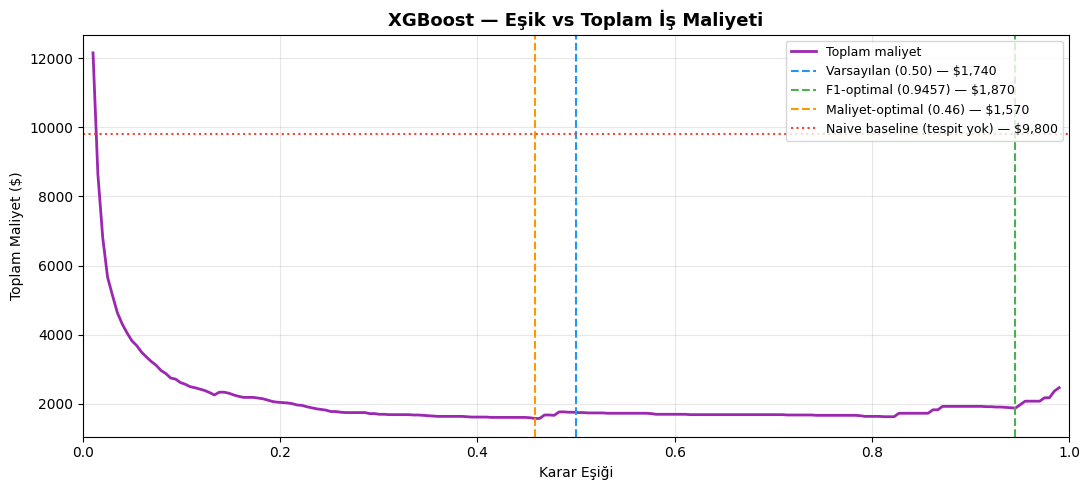

Saved: 21_cost_vs_threshold.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(thresholds, costs, color='#9C27B0', lw=2, label='Toplam maliyet')
ax.axvline(x=THRESHOLD_DEFAULT,      color='#2196F3', linestyle='--', lw=1.5,
           label=f'Varsayılan (0.50) — ${cost_default:,.0f}')
ax.axvline(x=THRESHOLD_F1_OPT,       color='#4CAF50', linestyle='--', lw=1.5,
           label=f'F1-optimal (0.9457) — ${cost_f1opt:,.0f}')
ax.axvline(x=best_cost_threshold,     color='#FF9800', linestyle='--', lw=1.5,
           label=f'Maliyet-optimal ({best_cost_threshold:.2f}) — ${best_cost_value:,.0f}')
ax.axhline(y=cost_naive, color='#F44336', linestyle=':', lw=1.5,
           label=f'Naive baseline (tespit yok) — ${cost_naive:,}')

ax.set_xlabel('Karar Eşiği')
ax.set_ylabel('Toplam Maliyet ($)')
ax.set_title('XGBoost — Eşik vs Toplam İş Maliyeti', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '21_cost_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 21_cost_vs_threshold.png')

## 3. Üç Eşiğin Karşılaştırması

In [6]:
scenarios = [
    ('Varsayılan', THRESHOLD_DEFAULT),
    ('F1-Optimal', THRESHOLD_F1_OPT),
    (f'Maliyet-Optimal', best_cost_threshold),
]

rows = []
for name, t in scenarios:
    y_pred_t = (y_pred_proba >= t).astype(int)
    cost, tn, fp, fn, tp = compute_cost(y_test, y_pred_t)
    rows.append({
        'Senaryo'  : f'{name} ({t:.4f})',
        'Precision': round(float(precision_score(y_test, y_pred_t, zero_division=0)), 4),
        'Recall'   : round(float(recall_score(y_test, y_pred_t, zero_division=0)), 4),
        'F1'       : round(float(f1_score(y_test, y_pred_t, zero_division=0)), 4),
        'TP': tp, 'FP': fp, 'FN': fn,
        'Maliyet ($)': cost,
    })

comp_df = pd.DataFrame(rows).set_index('Senaryo')
print('=== 3 Eşik Karşılaştırması ===')
print(comp_df.to_string())

=== 3 Eşik Karşılaştırması ===
                          Precision  Recall      F1  TP  FP  FN  Maliyet ($)
Senaryo                                                                     
Varsayılan (0.5000)          0.7757  0.8469  0.8098  83  24  15         1740
F1-Optimal (0.9457)          0.9195  0.8163  0.8649  80   7  18         1870
Maliyet-Optimal (0.4581)     0.7589  0.8673  0.8095  85  27  13         1570


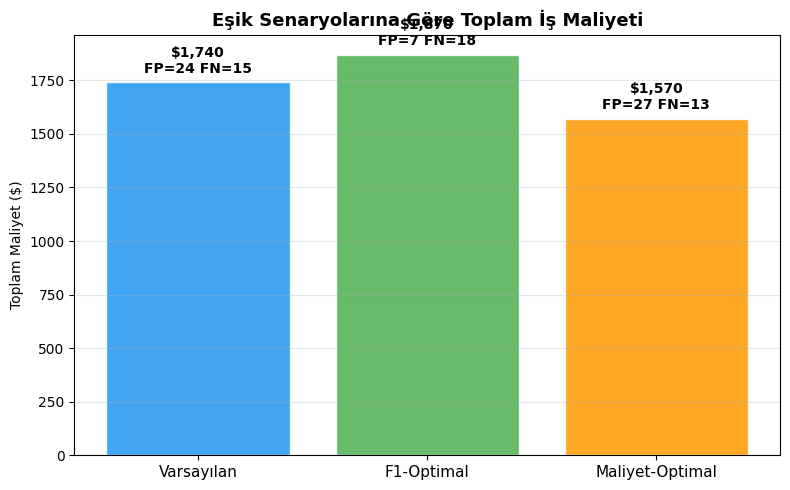

Saved: 22_cost_comparison_bar.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

scenario_labels = [r['Senaryo'] for r in rows]
cost_vals       = [r['Maliyet ($)'] for r in rows]
bar_colors      = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(range(len(scenario_labels)), cost_vals, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(scenario_labels)))
ax.set_xticklabels([s.split(' (')[0] for s in scenario_labels], fontsize=11)
ax.set_ylabel('Toplam Maliyet ($)')
ax.set_title('Eşik Senaryolarına Göre Toplam İş Maliyeti', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val, row in zip(bars, cost_vals, rows):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'${val:,}\nFP={row["FP"]} FN={row["FN"]}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '22_cost_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 22_cost_comparison_bar.png')

## 4. Sonuç Kaydet

In [8]:
result = {
    'step': '11_business_cost',
    'cost_assumptions': {'cost_fn_usd': COST_FN, 'cost_fp_usd': COST_FP},
    'naive_baseline_cost': int(cost_naive),
    'scenarios': [
        {
            'name'     : row['Senaryo'],
            'precision': row['Precision'],
            'recall'   : row['Recall'],
            'f1'       : row['F1'],
            'TP': row['TP'], 'FP': row['FP'], 'FN': row['FN'],
            'total_cost_usd': row['Maliyet ($)']
        }
        for row in rows
    ],
    'cost_optimal_threshold': round(float(best_cost_threshold), 4),
    'cost_optimal_total_usd': int(best_cost_value)
}

with open(METRICS_DIR / '11_business_cost_metrics.json', 'w') as f:
    json.dump(result, f, indent=2)

print(json.dumps(result, indent=2))
print('\nSaved: 11_business_cost_metrics.json')

{
  "step": "11_business_cost",
  "cost_assumptions": {
    "cost_fn_usd": 100,
    "cost_fp_usd": 10
  },
  "naive_baseline_cost": 9800,
  "scenarios": [
    {
      "name": "Varsay\u0131lan (0.5000)",
      "precision": 0.7757,
      "recall": 0.8469,
      "f1": 0.8098,
      "TP": 83,
      "FP": 24,
      "FN": 15,
      "total_cost_usd": 1740
    },
    {
      "name": "F1-Optimal (0.9457)",
      "precision": 0.9195,
      "recall": 0.8163,
      "f1": 0.8649,
      "TP": 80,
      "FP": 7,
      "FN": 18,
      "total_cost_usd": 1870
    },
    {
      "name": "Maliyet-Optimal (0.4581)",
      "precision": 0.7589,
      "recall": 0.8673,
      "f1": 0.8095,
      "TP": 85,
      "FP": 27,
      "FN": 13,
      "total_cost_usd": 1570
    }
  ],
  "cost_optimal_threshold": 0.4581,
  "cost_optimal_total_usd": 1570
}

Saved: 11_business_cost_metrics.json
